In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the Tips dataset (built into seaborn)
df = sns.load_dataset('tips')

# Take a quick look
df.head()

Matplotlib is building the font cache; this may take a moment.


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
# TASK 1

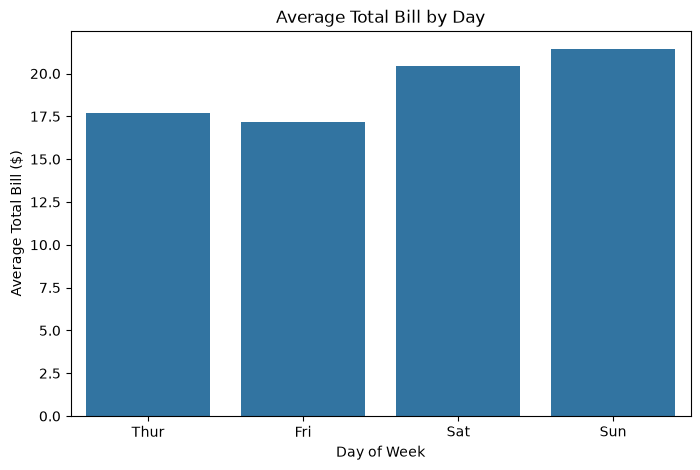

In [9]:
# Average total bill by day
avg_bill_by_day = df.groupby('day')['total_bill'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=avg_bill_by_day, x='day', y='total_bill')
plt.title('Average Total Bill by Day')
plt.xlabel('Day of Week')
plt.ylabel('Average Total Bill ($)')
plt.show()

In [10]:
# TASK 2

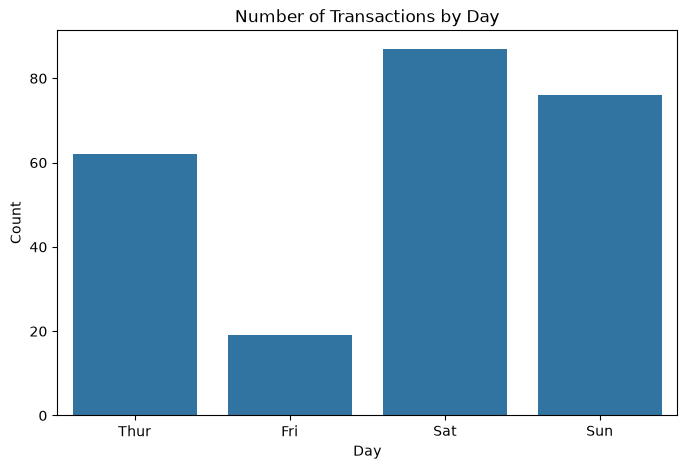

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='day')
plt.title('Number of Transactions by Day')
plt.xlabel('Day')
plt.ylabel('Count')
plt.show()

In [13]:
# TASK 3

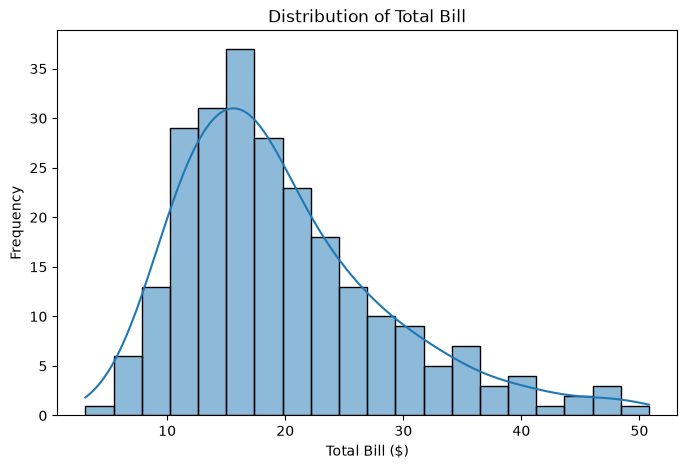

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['total_bill'], bins=20, kde=True)
plt.title('Distribution of Total Bill')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.show()

In [16]:
# DATA IS LEFT SKEWED WITH MOST Of THE BIlls BETWEEN 15 and 20 dollars

In [17]:
# TASK 4

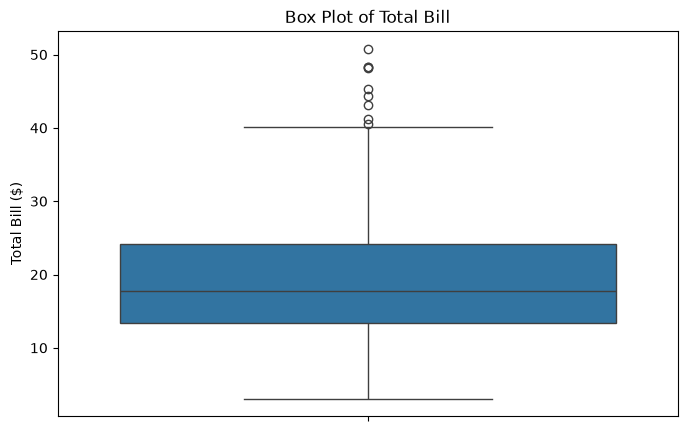

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, y='total_bill')
plt.title('Box Plot of Total Bill')
plt.ylabel('Total Bill ($)')
plt.show()

In [19]:
# 7 - 8 outliers

In [20]:
# TASK 5

In [21]:
col = df['total_bill']

Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[(col < lower) | (col > upper)]
print(f"Number of outliers (IQR): {len(outliers_iqr)}")
print(f"Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")

Number of outliers (IQR): 9
Lower bound: -2.82, Upper bound: 40.30


In [22]:
# TASK 6

In [23]:
z_scores = stats.zscore(col)
outliers_z = df[np.abs(z_scores) > 3]
print(f"Number of outliers (Z‑score): {len(outliers_z)}")

Number of outliers (Z‑score): 4


In [24]:
# TASK 7

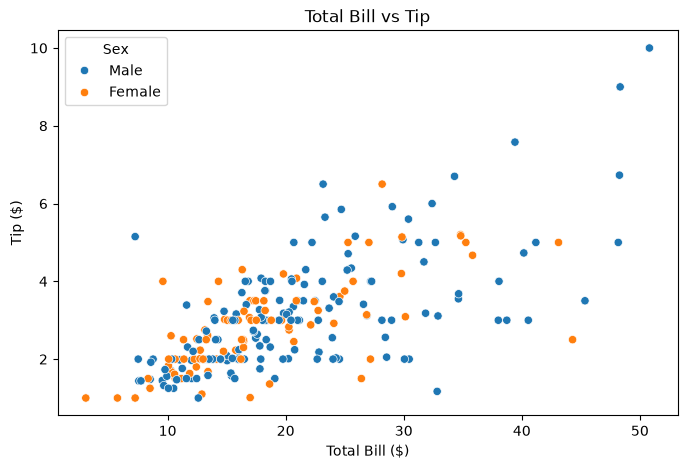

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex')
plt.title('Total Bill vs Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.legend(title='Sex')
plt.show()

In [26]:
# TASK 8

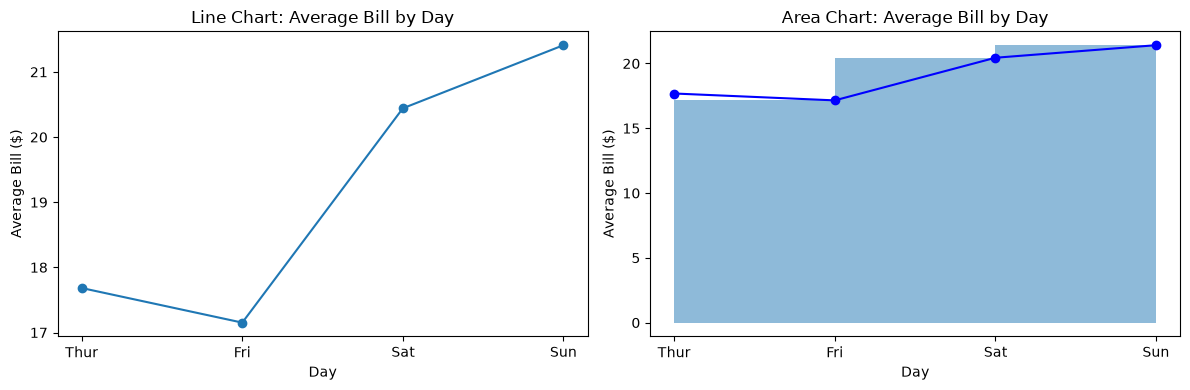

In [27]:
# Group by day (ordered)
ordered_days = ['Thur', 'Fri', 'Sat', 'Sun']
avg_by_day = df.groupby('day')['total_bill'].mean().reindex(ordered_days)

plt.figure(figsize=(12,4))

# Line chart
plt.subplot(1,2,1)
plt.plot(avg_by_day.index, avg_by_day.values, marker='o', linestyle='-')
plt.title('Line Chart: Average Bill by Day')
plt.xlabel('Day')
plt.ylabel('Average Bill ($)')

# Area chart
plt.subplot(1,2,2)
plt.fill_between(avg_by_day.index, avg_by_day.values, alpha=0.5, step='pre')
plt.plot(avg_by_day.index, avg_by_day.values, marker='o', linestyle='-', color='blue')
plt.title('Area Chart: Average Bill by Day')
plt.xlabel('Day')
plt.ylabel('Average Bill ($)')

plt.tight_layout()
plt.show()

In [28]:
# TASK 9

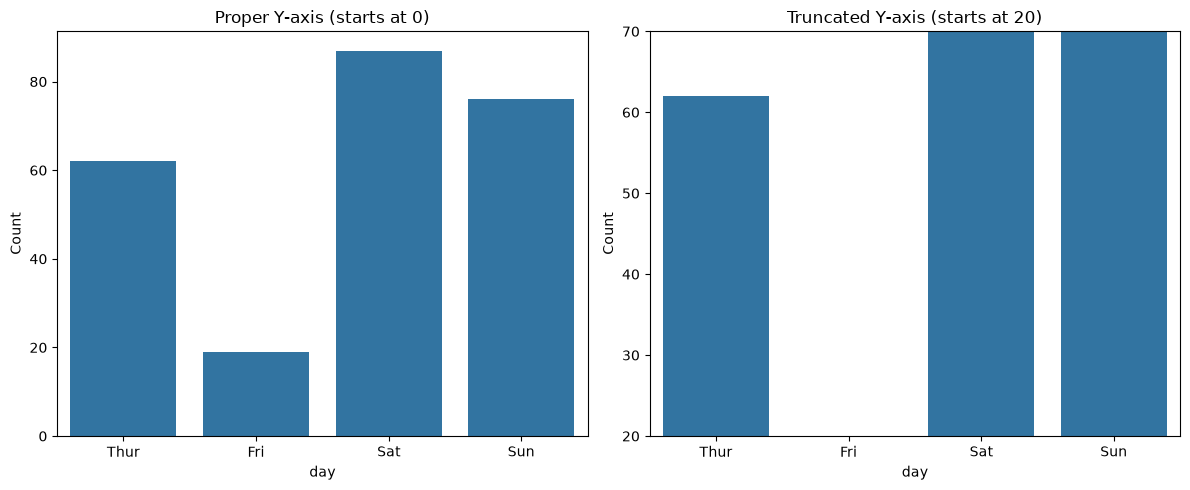

In [29]:
# Original (proper) count plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(data=df, x='day', order=ordered_days)
plt.ylim(0, None)  # starts at 0
plt.title('Proper Y‑axis (starts at 0)')
plt.ylabel('Count')

# Truncated (misleading)
plt.subplot(1,2,2)
sns.countplot(data=df, x='day', order=ordered_days)
plt.ylim(20, 70)   # start above minimum
plt.title('Truncated Y‑axis (starts at 20)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()